<a href="https://colab.research.google.com/github/HillaryDrugs/li7/blob/main/GRU_(Seq2Seq).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully merged into aligned_ara_model3.txt
Starting Training for Model 3 (GRU) on cuda...
Epoch 1 | Loss: 6.3033 | PPL: 546.385
Epoch 2 | Loss: 5.1279 | PPL: 168.665
Epoch 3 | Loss: 4.2502 | PPL:  70.121
Epoch 4 | Loss: 3.3906 | PPL:  29.684
Epoch 5 | Loss: 2.6094 | PPL:  13.590
Epoch 6 | Loss: 1.9184 | PPL:   6.810
Epoch 7 | Loss: 1.4584 | PPL:   4.299
Epoch 8 | Loss: 1.1422 | PPL:   3.134
Epoch 9 | Loss: 0.9152 | PPL:   2.497
Epoch 10 | Loss: 0.7212 | PPL:   2.057


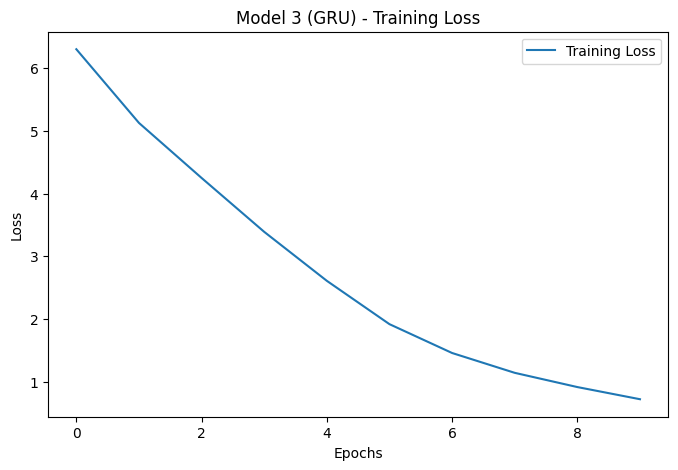


Calculating Final BLEU Score...
Final Test BLEU Score for Model 3: 0.1137


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import re
import random
import os
import time
import math
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ==========================================
# 1. DATA PREPARATION (Merging Tatoeba Files)
# ==========================================
EN_FILE = 'Tatoeba.ar-en.en'
AR_FILE = 'Tatoeba.ar-en.ar'
MERGED_FILE = 'aligned_ara_model3.txt'

if os.path.exists(EN_FILE) and os.path.exists(AR_FILE):
    with open(EN_FILE, 'r', encoding='utf-8') as f_en, \
         open(AR_FILE, 'r', encoding='utf-8') as f_ar, \
         open(MERGED_FILE, 'w', encoding='utf-8') as f_out:
        for en_line, ar_line in zip(f_en, f_ar):
            f_out.write(f"{en_line.strip()}\t{ar_line.strip()}\n")
    print(f"Dataset successfully merged into {MERGED_FILE}")
else:
    raise FileNotFoundError("Please ensure Tatoeba.ar-en.en and Tatoeba.ar-en.ar are uploaded.")

def clean_text(text, is_arabic=False):
    text = str(text).lower().strip()
    text = re.sub(r"([?.!,¿])", r" \1 ", text)
    if not is_arabic:
        text = re.sub(r"[^a-zA-Z?.!,¿]+", " ", text)
    return text.strip()

class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.count = 4
    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.count
                self.idx2word[self.count] = word
                self.count += 1

# Process Data and Build Vocab
df = pd.read_csv(MERGED_FILE, sep='\t', names=['English', 'Arabic'], header=None)
df['English'] = df['English'].apply(lambda x: clean_text(x, False))
df['Arabic'] = df['Arabic'].apply(lambda x: clean_text(x, True))

en_vocab, ar_vocab = Vocab(), Vocab()
for _, row in df.iterrows():
    en_vocab.add_sentence(row['English'])
    ar_vocab.add_sentence(row['Arabic'])

class TranslationDataset(Dataset):
    def __init__(self, dataframe, en_v, ar_v, max_len=25):
        self.df, self.en_v, self.ar_v, self.max_len = dataframe, en_v, ar_v, max_len
    def tokenize(self, text, vocab):
        tokens = [vocab.word2idx.get(w, 3) for w in text.split()][:self.max_len-2]
        return [1] + tokens + [2] + [0] * (self.max_len - len(tokens) - 2)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return torch.tensor(self.tokenize(self.df.iloc[idx]['English'], self.en_v)), \
               torch.tensor(self.tokenize(self.df.iloc[idx]['Arabic'], self.ar_v))

train_df, test_df = train_test_split(df, test_size=0.1)
train_loader = DataLoader(TranslationDataset(train_df, en_vocab, ar_vocab), batch_size=64, shuffle=True)
test_dataset = TranslationDataset(test_df, en_vocab, ar_vocab)

# ==========================================
# 2. MODEL 3 ARCHITECTURE: GRU SEQ2SEQ
# ==========================================
class EncoderGRU(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
    def forward(self, src):
        _, hidden = self.rnn(self.embedding(src))
        return hidden

class DecoderGRU(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.out = nn.Linear(hid_dim, output_dim)
    def forward(self, input, hidden):
        output, hidden = self.rnn(self.embedding(input.unsqueeze(1)), hidden)
        return self.out(output.squeeze(1)), hidden

class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder, self.decoder, self.device = encoder, decoder, device
    def forward(self, src, trg, tf_ratio=0.5):
        batch_size, trg_len = trg.shape
        outputs = torch.zeros(batch_size, trg_len, self.decoder.out.out_features).to(self.device)
        hidden = self.encoder(src)
        input_step = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_step, hidden)
            outputs[:, t] = output
            input_step = trg[:, t] if random.random() < tf_ratio else output.argmax(1)
        return outputs

# ==========================================
# 3. TRAINING, VISUALIZATION, & EVALUATION
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Seq2SeqGRU(EncoderGRU(en_vocab.count, 256, 512),
                   DecoderGRU(ar_vocab.count, 256, 512), DEVICE).to(DEVICE)
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=0)

train_losses = []
print(f"Starting Training for Model 3 (GRU) on {DEVICE}...")

for epoch in range(10): # Standard 10 epochs for comparison
    model.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, trg)
        loss = criterion(output[:, 1:].reshape(-1, ar_vocab.count), trg[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | PPL: {math.exp(avg_loss):7.3f}")

# Plotting the Training Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.title('Model 3 (GRU) - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Final BLEU Calculation
model.eval()
total_bleu = 0
smooth = SmoothingFunction().method1
print("\nCalculating Final BLEU Score...")
with torch.no_grad():
    for i in range(200): # Test on 200 samples
        src, trg = test_dataset[i]
        hidden = model.encoder(src.unsqueeze(0).to(DEVICE))
        curr_in, res = torch.tensor([1]).to(DEVICE), [] # <SOS>
        for _ in range(25):
            out, hidden = model.decoder(curr_in, hidden)
            top1 = out.argmax(1)
            if top1.item() == 2: break # <EOS>
            res.append(ar_vocab.idx2word[top1.item()])
            curr_in = top1
        ref = [ar_vocab.idx2word[t.item()] for t in trg if t.item() > 3]
        total_bleu += sentence_bleu([ref], res, smoothing_function=smooth)

print(f"Final Test BLEU Score for Model 3: {total_bleu/200:.4f}")